<a href="https://colab.research.google.com/github/Sajjad5/causal-portfolio-risk/blob/main/Causal_Attribution_Portfolio_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**1. Data Collection**

**Objective**

The first step is to collect financial and macroeconomic variables that may influence portfolio performance.

**We need:**

**Market Variables**

* S&P 500 (US Equity Market)
* DAX (German Equity Market)
* VIX (Market Fear Index)
* EUR/USD Exchange Rate
* Macroeconomic Variables
* US Treasury Yields
* Inflation (CPI)
* Industrial Production
* Economic Sentiment Indicators

These variables will later be used for causal discovery and causal inference.

**Why?**

Traditional risk models assume correlation.

**For example:**

**VIX ↑ and Portfolio ↓**

But correlation alone cannot tell us whether VIX actually causes portfolio losses.

Therefore we collect potential causal drivers first.

In [1]:
# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================

!pip install yfinance fredapi causal-learn dowhy econml graphviz pydot networkx --quiet

In [2]:
# ============================================================
# 1.1 IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import yfinance as yf

from fredapi import Fred

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import networkx as nx

# 2. Define Research Parameters

Here we define the full research period and the stress window.

The stress window is based on the Iran–USA conflict period:

28 February 2026 to 31 March 2026

This period is used to compare normal market behavior with geopolitical stress behavior.

In [3]:
# ============================================================
# 2. RESEARCH TIME PERIOD
# ============================================================

START_DATE = "2018-01-01"
END_DATE = "2026-04-15"

# Iran-USA War / Conflict Stress Window
WAR_START = "2026-02-28"
WAR_END = "2026-03-31"

#3. Define Market Risk Factors

**Explanation**

We select financial variables that represent different portfolio risk channels.

* SP500	US equity risk
* DAX	German equity risk
* VIX	volatility / fear index
* EURUSD	currency risk
* GOLD	safe-haven asset
* OIL	energy / geopolitical risk
* US Treasury ETF	interest-rate exposure



In [4]:
# ============================================================
# 3. MARKET RISK FACTORS
# ============================================================

market_tickers = {
    "SP500": "^GSPC",
    "DAX": "^GDAXI",
    "VIX": "^VIX",
    "EURUSD": "EURUSD=X",
    "GOLD": "GC=F",
    "OIL": "CL=F",
    "US_TREASURY_ETF": "IEF"
}

# 4. Download Market Data

**Explanation**

We download adjusted closing prices from Yahoo Finance.

Adjusted prices are used because they are more suitable for return calculation.

In [5]:
# ============================================================
# 4. DOWNLOAD MARKET PRICES
# ============================================================

market_prices = pd.DataFrame()

for name, ticker in market_tickers.items():
    print(f"Downloading {name}: {ticker}")

    temp = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        progress=False
    )

    market_prices[name] = temp["Close"]

market_prices.head()

,SP500,DAX,VIX,EURUSD,GOLD,OIL,US_TREASURY_ETF
Date,,,,,,,
2018-01-02,2695.810059,12871.389648,9.77,1.201158,1313.699951,60.369999,86.111000
2018-01-03,2713.060059,12978.209961,9.15,1.206345,1316.199951,61.630001,86.200989
2018-01-04,2723.989990,13167.889648,9.22,1.201043,1319.400024,62.009998,86.160065
2018-01-05,2743.149902,13319.639648,9.22,1.206884,1320.300049,61.439999,86.053680
2018-01-08,2747.709961,13367.780273,9.52,1.203746,1318.599976,61.730000,86.012787


In [6]:
market_prices.head()

,SP500,DAX,VIX,EURUSD,GOLD,OIL,US_TREASURY_ETF
Date,,,,,,,
2018-01-02,2695.810059,12871.389648,9.77,1.201158,1313.699951,60.369999,86.111000
2018-01-03,2713.060059,12978.209961,9.15,1.206345,1316.199951,61.630001,86.200989
2018-01-04,2723.989990,13167.889648,9.22,1.201043,1319.400024,62.009998,86.160065
2018-01-05,2743.149902,13319.639648,9.22,1.206884,1320.300049,61.439999,86.053680
2018-01-08,2747.709961,13367.780273,9.52,1.203746,1318.599976,61.730000,86.012787


In [7]:
# ============================================================
# 4.1 CHECK MISSING VALUES
# ============================================================

print("Dataset shape:", market_prices.shape)
print(market_prices.isna().sum())

Dataset shape: (2081, 7)
SP500               0
DAX                37
VIX                 0
EURUSD              2
GOLD                1
OIL                 0
US_TREASURY_ETF     0
dtype: int64


# 5. Download Macroeconomic Data

**Explanation**

Market movements are often caused by macroeconomic forces.

We include interest rates, inflation, and industrial production to reduce omitted-variable bias.

In [8]:
# ============================================================
# 5. FRED API SETUP
# ============================================================

FRED_API_KEY = "fbf67578fdd8839127161f1709548ce7"

fred = Fred(api_key=FRED_API_KEY)

In [9]:
# ============================================================
# 5.1 FRED MACRO SERIES
# ============================================================

fred_series = {
    "US10Y": "DGS10",
    "US2Y": "DGS2",
    "FEDFUNDS": "FEDFUNDS",
    "CPI_US": "CPIAUCSL",
    "INDPRO_US": "INDPRO"
}

In [10]:
import time
# ============================================================
# 5.2 DOWNLOAD MACRO DATA
# ============================================================

macro_data = pd.DataFrame()

for name, code in fred_series.items():
    print(f"Downloading {name}: {code}")

    macro_data[name] = fred.get_series(
        code,
        observation_start=START_DATE,
        observation_end=END_DATE
    )
    time.sleep(1) # Add a delay to avoid rate limits

macro_data.head()

,US10Y,US2Y,FEDFUNDS,CPI_US,INDPRO_US
2018-01-01,NaN,NaN,1.41,248.859,101.4625
2018-01-02,2.46,1.92,NaN,NaN,NaN
2018-01-03,2.44,1.94,NaN,NaN,NaN
2018-01-04,2.46,1.96,NaN,NaN,NaN
2018-01-05,2.47,1.96,NaN,NaN,NaN


In [11]:
# ============================================================
# 5.3 HANDLE MISSING VALUES IN MACRO DATA
# ============================================================

print("Missing values before handling:")
print(macro_data.isnull().sum())

Missing values before handling:
US10Y          92
US2Y           92
FEDFUNDS     2092
CPI_US       2093
INDPRO_US    2092
dtype: int64


In [12]:
# Use forward fill to handle missing values
macro_data_filled = macro_data.ffill()

print("\nMissing values after forward fill:")
print(macro_data_filled.isnull().sum())

display(macro_data_filled.head())


Missing values after forward fill:
US10Y        1
US2Y         1
FEDFUNDS     0
CPI_US       0
INDPRO_US    0
dtype: int64


,US10Y,US2Y,FEDFUNDS,CPI_US,INDPRO_US
2018-01-01,NaN,NaN,1.41,248.859,101.4625
2018-01-02,2.46,1.92,1.41,248.859,101.4625
2018-01-03,2.44,1.94,1.41,248.859,101.4625
2018-01-04,2.46,1.96,1.41,248.859,101.4625
2018-01-05,2.47,1.96,1.41,248.859,101.4625


In [13]:
# Apply backward fill to handle any remaining initial NaN values
macro_data_filled = macro_data_filled.bfill()

print("\nMissing values after backward fill:")
print(macro_data_filled.isnull().sum())

display(macro_data_filled.head())


Missing values after backward fill:
US10Y        0
US2Y         0
FEDFUNDS     0
CPI_US       0
INDPRO_US    0
dtype: int64


,US10Y,US2Y,FEDFUNDS,CPI_US,INDPRO_US
2018-01-01,2.46,1.92,1.41,248.859,101.4625
2018-01-02,2.46,1.92,1.41,248.859,101.4625
2018-01-03,2.44,1.94,1.41,248.859,101.4625
2018-01-04,2.46,1.96,1.41,248.859,101.4625
2018-01-05,2.47,1.96,1.41,248.859,101.4625


#6. Feature Engineering

**Explanation**

We convert price levels into log returns.

Returns are better for risk modeling because prices are usually non-stationary.

For macro variables, we use changes and growth rates.

In [14]:
# ============================================================
# 6. MARKET LOG RETURNS
# ============================================================

market_returns = np.log(
    market_prices / market_prices.shift(1)
)

market_returns = market_returns.add_suffix("_RET")

market_returns.head()

,SP500_RET,DAX_RET,VIX_RET,EURUSD_RET,GOLD_RET,OIL_RET,US_TREASURY_ETF_RET
Date,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,0.006378,0.008265,-0.065563,0.004309,0.001901,0.020657,0.001044
2018-01-04,0.004021,0.014509,0.007621,-0.004406,0.002428,0.006147,-0.000475
2018-01-05,0.007009,0.011458,0.000000,0.004852,0.000682,-0.009235,-0.001235
2018-01-08,0.001661,0.003608,0.032020,-0.002603,-0.001288,0.004709,-0.000475


In [23]:
# ============================================================
# 6.1 MACRO FEATURES
# ============================================================

macro_features = pd.DataFrame(index=macro_data_filled.index)

macro_features["US10Y_CHANGE"] = macro_data_filled["US10Y"].diff()
macro_features["US2Y_CHANGE"] = macro_data_filled["US2Y"].diff()
macro_features["FEDFUNDS_CHANGE"] = macro_data_filled["FEDFUNDS"].diff()

macro_features["TERM_SPREAD"] = macro_data_filled["US10Y"] - macro_data_filled["US2Y"]

macro_features["CPI_US_GROWTH"] = np.log(
    macro_data_filled["CPI_US"] / macro_data_filled["CPI_US"].shift(1)
)

macro_features["INDPRO_US_GROWTH"] = np.log(
    macro_data_filled["INDPRO_US"] / macro_data_filled["INDPRO_US"].shift(1)
)

macro_features.head()

,US10Y_CHANGE,US2Y_CHANGE,FEDFUNDS_CHANGE,TERM_SPREAD,CPI_US_GROWTH,INDPRO_US_GROWTH
2018-01-01,NaN,NaN,NaN,0.54,NaN,NaN
2018-01-02,0.00,0.00,0.0,0.54,0.0,0.0
2018-01-03,-0.02,0.02,0.0,0.50,0.0,0.0
2018-01-04,0.02,0.02,0.0,0.50,0.0,0.0
2018-01-05,0.01,0.00,0.0,0.51,0.0,0.0


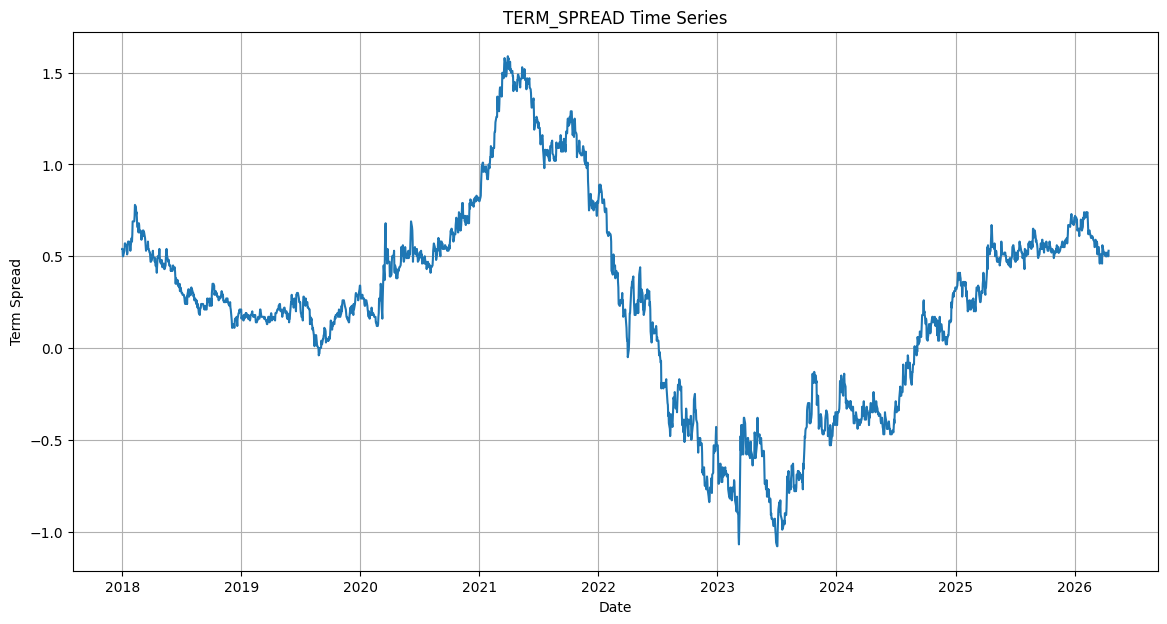

In [16]:
# ============================================================
# 6.2 PLOT TERM_SPREAD TIME SERIES
# ============================================================

plt.figure(figsize=(14, 7))
plt.plot(macro_features.index, macro_features['TERM_SPREAD'])
plt.title('TERM_SPREAD Time Series')
plt.xlabel('Date')
plt.ylabel('Term Spread')
plt.grid(True)
plt.show()

#7. Merge Dataset

**Explanation**

Yahoo data is daily. FRED macro data can be daily, monthly, or lower frequency.

Therefore:

we merge by date,
forward-fill macro data,
remove missing values.

In [17]:
# ============================================================
# 7. MERGE MARKET AND MACRO DATA
# ============================================================

full_data = pd.concat(
    [market_returns, macro_features],
    axis=1
)

full_data = full_data.sort_index()
full_data = full_data.ffill().bfill() # Apply both ffill and bfill to handle all NaNs
full_data = full_data.dropna()

full_data.head()

,SP500_RET,DAX_RET,VIX_RET,EURUSD_RET,GOLD_RET,OIL_RET,US_TREASURY_ETF_RET,US10Y_CHANGE,US2Y_CHANGE,FEDFUNDS_CHANGE,TERM_SPREAD,CPI_US_GROWTH,INDPRO_US_GROWTH
2018-01-01,0.006378,0.008265,-0.065563,0.004309,0.001901,0.020657,0.001044,0.00,0.00,0.0,0.54,0.0,0.0
2018-01-02,0.006378,0.008265,-0.065563,0.004309,0.001901,0.020657,0.001044,0.00,0.00,0.0,0.54,0.0,0.0
2018-01-03,0.006378,0.008265,-0.065563,0.004309,0.001901,0.020657,0.001044,-0.02,0.02,0.0,0.50,0.0,0.0
2018-01-04,0.004021,0.014509,0.007621,-0.004406,0.002428,0.006147,-0.000475,0.02,0.02,0.0,0.50,0.0,0.0
2018-01-05,0.007009,0.011458,0.000000,0.004852,0.000682,-0.009235,-0.001235,0.01,0.00,0.0,0.51,0.0,0.0


#8. Portfolio Construction

Explanation

We now create the portfolio return.

This is the main outcome variable.

Example portfolio:

  Asset>>Weight
* SP500	 40%
* DAX	   25%
* US Treasury ETF	20%
* EUR/USD	10%
* Gold	5%

In [18]:
# ============================================================
# 8. PORTFOLIO WEIGHTS
# ============================================================

portfolio_weights = {
    "SP500_RET": 0.40,
    "DAX_RET": 0.25,
    "US_TREASURY_ETF_RET": 0.20,
    "EURUSD_RET": 0.10,
    "GOLD_RET": 0.05
}

In [19]:
# ============================================================
# 8.1 CALCULATE PORTFOLIO RETURNS
# ============================================================

full_data["PORTFOLIO_RET"] = 0

for asset, weight in portfolio_weights.items():
    full_data["PORTFOLIO_RET"] += weight * full_data[asset]

full_data[["PORTFOLIO_RET"]].head()

,PORTFOLIO_RET
2018-01-01,0.005352
2018-01-02,0.005352
2018-01-03,0.005352
2018-01-04,0.004821
2018-01-05,0.005940


#9. Create War Regime Indicator

**Explanation**

This variable separates normal observations from the Iran–USA war stress period.

0 = normal regime
1 = Iran–USA war stress regime

In [20]:
# ============================================================
# 9. IRAN-USA WAR REGIME INDICATOR
# ============================================================

full_data["IRAN_USA_WAR_REGIME"] = 0

full_data.loc[
    WAR_START:WAR_END,
    "IRAN_USA_WAR_REGIME"
] = 1

full_data["IRAN_USA_WAR_REGIME"].value_counts()

,count
IRAN_USA_WAR_REGIME,
0,2141
1,22


In [21]:
# ============================================================
# 9.1 SPLIT NORMAL AND WAR DATA
# ============================================================

war_data = full_data.loc[WAR_START:WAR_END]

normal_data = full_data[
    full_data["IRAN_USA_WAR_REGIME"] == 0
]

print("Full sample observations:", len(full_data))
print("Normal observations:", len(normal_data))
print("War observations:", len(war_data))

Full sample observations: 2163
Normal observations: 2141
War observations: 22


#10. Standardize Data

**Explanation**

Causal discovery algorithms work better when variables are on the same scale.

Standardization transforms each variable to:

mean = 0
standard deviation = 1

In [22]:
# ============================================================
# 10. STANDARDIZATION
# ============================================================

features_for_model = full_data.drop(
    columns=["IRAN_USA_WAR_REGIME"]
)

scaler = StandardScaler()

scaled_array = scaler.fit_transform(features_for_model)

scaled_data = pd.DataFrame(
    scaled_array,
    columns=features_for_model.columns,
    index=features_for_model.index
)

scaled_data["IRAN_USA_WAR_REGIME"] = full_data["IRAN_USA_WAR_REGIME"]

scaled_data.head()

,SP500_RET,DAX_RET,VIX_RET,EURUSD_RET,GOLD_RET,OIL_RET,US_TREASURY_ETF_RET,US10Y_CHANGE,US2Y_CHANGE,FEDFUNDS_CHANGE,TERM_SPREAD,CPI_US_GROWTH,INDPRO_US_GROWTH,PORTFOLIO_RET,IRAN_USA_WAR_REGIME
2018-01-01,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226695,-0.015485,-0.015115,-0.01841,0.531771,-0.122327,-0.00106,0.711709,0
2018-01-02,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226695,-0.015485,-0.015115,-0.01841,0.531771,-0.122327,-0.00106,0.711709,0
2018-01-03,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226695,-0.381550,0.340254,-0.01841,0.458542,-0.122327,-0.00106,0.711709,0
2018-01-04,0.288781,1.170737,0.101123,-0.962578,0.160123,0.189408,-0.123048,0.350579,0.340254,-0.01841,0.458542,-0.122327,-0.00106,0.636128,0
2018-01-05,0.534727,0.917659,0.007289,1.052094,-0.002131,-0.320938,-0.298139,0.167547,-0.015115,-0.01841,0.476849,-0.122327,-0.00106,0.795396,0


## 11. Basic Portfolio Risk Metrics

**Explanation**

Before causal analysis, we calculate traditional risk metrics:

* volatility,
* VaR,
* expected shortfall,
* skewness,
* kurtosis.

This gives us a baseline risk view.

In [25]:
# ============================================================
# 11. RISK METRICS FUNCTION
# ============================================================

def calculate_risk_metrics(returns, alpha=0.05):
    var = np.percentile(returns, alpha * 100)
    expected_shortfall = returns[returns <= var].mean()

    return {
        "Mean": returns.mean(),
        "Volatility": returns.std(),
        "Skewness": returns.skew(),
        "Kurtosis": returns.kurtosis(),
        "VaR_95": var,
        "Expected_Shortfall_95": expected_shortfall
    }

In [26]:
# ============================================================
# 11.1 COMPARE NORMAL VS WAR RISK
# ============================================================

normal_metrics = calculate_risk_metrics(
    normal_data["PORTFOLIO_RET"]
)

war_metrics = calculate_risk_metrics(
    war_data["PORTFOLIO_RET"]
)

risk_comparison = pd.DataFrame({
    "Normal_Regime": normal_metrics,
    "Iran_USA_War_Regime": war_metrics
})

risk_comparison

,Normal_Regime,Iran_USA_War_Regime
Mean,0.000385,-0.002802
Volatility,0.007007,0.008378
Skewness,-0.887367,0.296582
Kurtosis,15.756117,-1.006725
VaR_95,-0.010178,-0.014708
Expected_Shortfall_95,-0.016706,-0.014966


#12. Visualize Portfolio Returns

**Explanation**

This chart shows whether the war period had larger losses or higher volatility.

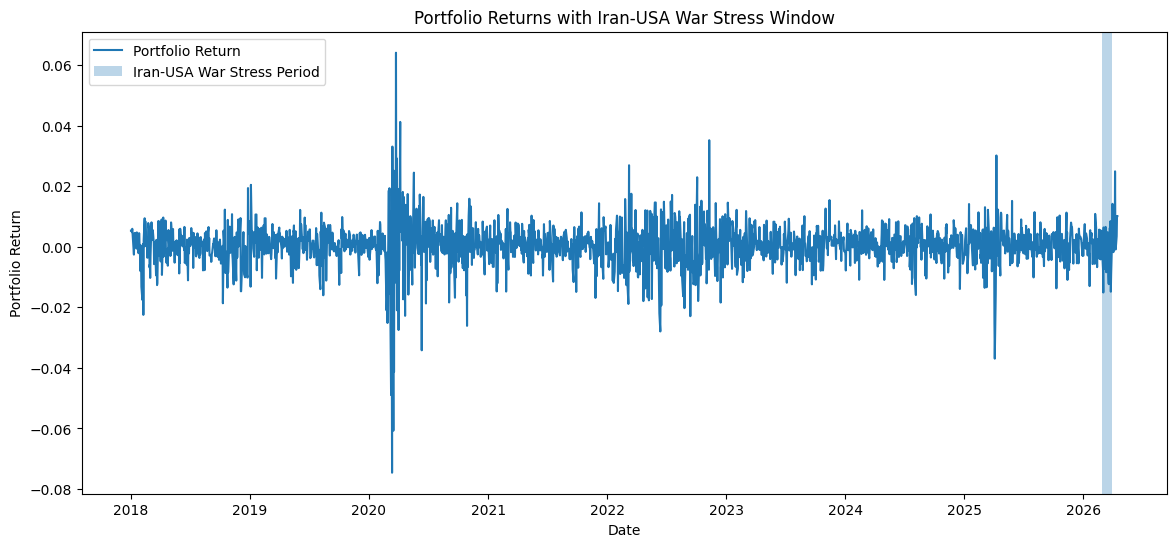

In [27]:
# ============================================================
# 12. PORTFOLIO RETURN VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    full_data.index,
    full_data["PORTFOLIO_RET"],
    label="Portfolio Return"
)

plt.axvspan(
    pd.to_datetime(WAR_START),
    pd.to_datetime(WAR_END),
    alpha=0.3,
    label="Iran-USA War Stress Period"
)

plt.title("Portfolio Returns with Iran-USA War Stress Window")
plt.xlabel("Date")
plt.ylabel("Portfolio Return")
plt.legend()
plt.show()